In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("C:/Users/12sha/OneDrive/Desktop/MP_6thSem/data/Synthetic_industrial_sensor_data_V4.csv")

In [3]:
df.head()

,time,temperature,vibration,sound,anomaly
0,0,30.250858,0.070158,44.624015,0.0
1,1,29.922393,0.363687,45.992177,0.0
2,2,30.302469,0.395606,45.199860,0.0
3,3,30.742020,0.920135,45.610246,0.0
4,4,29.866523,0.648560,46.283103,0.0


In [4]:
features = ["temperature", "vibration", "sound"]
X = df[features]

### TRAIN-TEST SPLIT

In [5]:
train_size = int(0.7 * len(df))

In [6]:
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

In [7]:
y_test = df["anomaly"].iloc[train_size:]

### Scaling

In [8]:
scaler = StandardScaler()

In [9]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
X_train_normal = X_train_scaled[df["anomaly"].iloc[:train_size] == 0]

### Training

##### Model-1 

In [41]:
model = IsolationForest(
    n_estimators = 100,
    contamination= "auto",
    random_state = 42
)

In [42]:
model.fit(X_train_scaled)

IsolationForest(random_state=42)

In [43]:
y_pred = model.predict(X_test_scaled)

In [44]:
# Convert: 1-> normal, -1 -> anomaly
y_pred = np.where(y_pred == -1, 1, 0)

In [45]:
print(y_pred)

[1 1 1 ... 1 1 1]


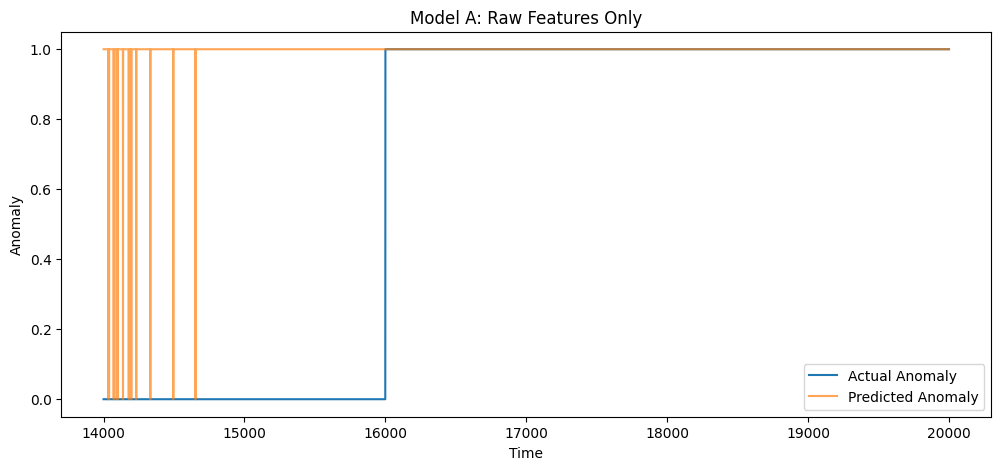

In [46]:
plt.figure(figsize=(12, 5))
plt.plot(df.index[train_size:], y_test, label= "Actual Anomaly")
plt.plot(df.index[train_size:], y_pred, label = "Predicted Anomaly", alpha=0.7)
plt.legend()
plt.title("Model A: Raw Features Only")
plt.xlabel("Time")
plt.ylabel("Anomaly")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.01      0.01      2000
         1.0       0.67      1.00      0.80      4000

    accuracy                           0.67      6000
   macro avg       0.83      0.50      0.41      6000
weighted avg       0.78      0.67      0.54      6000



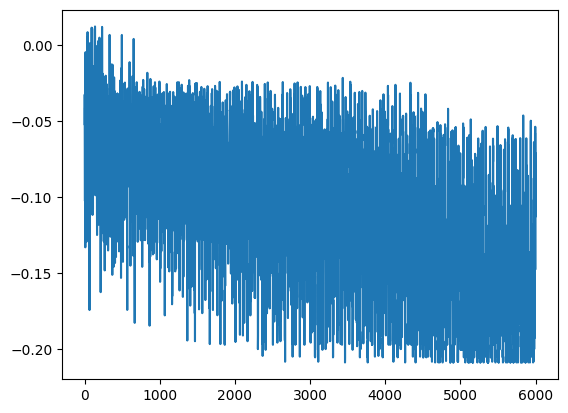

In [48]:
scores = model.decision_function(X_test_scaled)
plt.plot(scores)

##### Model-2

In [49]:
model2 = IsolationForest(
    n_estimators = 100,
    contamination = "auto",
    random_state= 42
)

In [53]:
model2.fit(X_train_normal)

IsolationForest(random_state=42)

In [54]:
y_pred = model2.predict(X_test_scaled)

In [55]:
# Convert: 1 -> normal, -1 -> anomaly
y_pred = np.where(y_pred == -1, 1, 0)

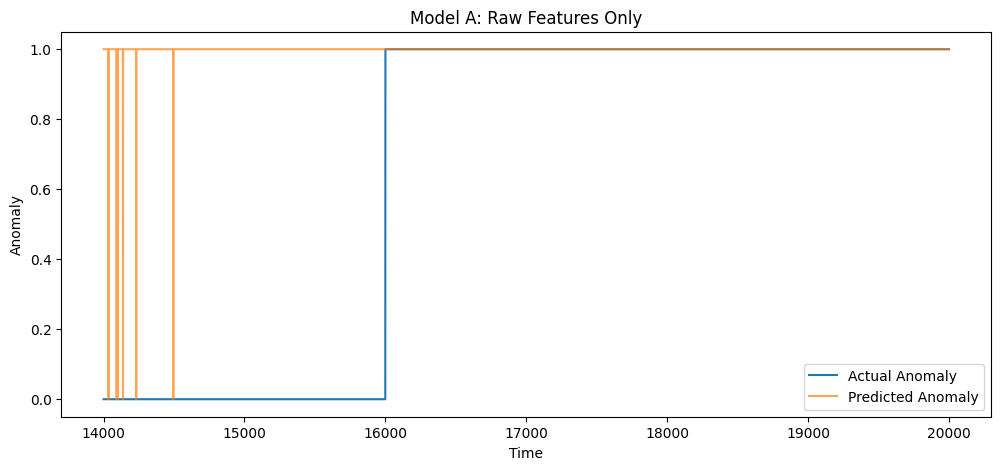

In [56]:
# Visualization
plt.figure(figsize=(12, 5))
plt.plot(df.index[train_size:], y_test, label= "Actual Anomaly")
plt.plot(df.index[train_size:], y_pred, label = "Predicted Anomaly", alpha=0.7)
plt.legend()
plt.title("Model A: Raw Features Only")
plt.xlabel("Time")
plt.ylabel("Anomaly")
plt.show()

In [57]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.00      0.01      2000
         1.0       0.67      1.00      0.80      4000

    accuracy                           0.67      6000
   macro avg       0.83      0.50      0.40      6000
weighted avg       0.78      0.67      0.54      6000



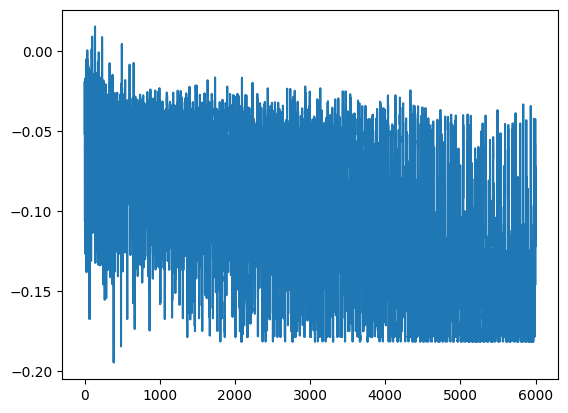

In [58]:
scores = model2.decision_function(X_test_scaled)
plt.plot(scores)